In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
sys.path.append(os.path.abspath(".."))

from src.read_code15 import load_metadata as load_code
from src.read_code15 import get_ecg_by_exam_id as get_code_ecg

EDA of metadata

In [3]:
#Load data
code_df = load_code()

#Remove death and timey columns
code_df = code_df.drop(columns=["death", "timey", "nn_predicted_age", "dataset"])
print("Shape:", code_df.shape)
print("\nColumns:")
print(code_df.columns.tolist())
print("\nChagas counts:")
print(code_df["chagas"].value_counts())
code_df

Shape: (343424, 13)

Columns:
['exam_id', 'age', 'is_male', '1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF', 'patient_id', 'normal_ecg', 'trace_file', 'chagas']

Chagas counts:
chagas
0    336863
1      6561
Name: count, dtype: int64


,exam_id,age,is_male,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,normal_ecg,trace_file,chagas
0,1169160,38,True,False,False,False,False,False,False,523632,True,exams_part13.hdf5,0
1,2873686,73,True,False,False,False,False,False,False,1724173,False,exams_part13.hdf5,0
2,168405,67,True,False,False,False,False,False,True,51421,False,exams_part13.hdf5,0
3,271011,41,True,False,False,False,False,False,False,1737282,True,exams_part13.hdf5,0
4,384368,73,True,False,False,False,False,False,False,331652,False,exams_part13.hdf5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343419,1123951,33,True,False,False,False,False,False,False,770553,True,exams_part2.hdf5,0
343420,954704,73,False,False,False,False,False,False,False,1044781,False,exams_part2.hdf5,0
343421,589697,75,False,False,False,False,False,False,False,1020589,False,exams_part2.hdf5,0
343422,2780563,44,False,False,False,False,False,False,False,178,False,exams_part2.hdf5,0


In [5]:
code_df["chagas"].value_counts()
code_df["chagas"].value_counts(normalize=True) * 100

chagas
0    98.089534
1     1.910466
Name: proportion, dtype: float64

In [6]:
abnormalities = ["RBBB", "1dAVb", "AF", "LBBB", "SB", "ST"]

table = []

for col in abnormalities:
    if col in code_df.columns:
        vals = code_df.groupby("chagas")[col].mean() * 100
        
        table.append({
            "Abnormality": col,
            "Non-Chagas (%)": vals.get(0, 0),
            "Chagas (%)": vals.get(1, 0)
        })

import pandas as pd
df_table = pd.DataFrame(table)
df_table = df_table.round(2)
print(df_table)

  Abnormality  Non-Chagas (%)  Chagas (%)
0        RBBB            2.43       19.97
1       1dAVb            1.60        4.07
2          AF            1.94        6.16
3        LBBB            1.71        3.40
4          SB            1.59        3.17
5          ST            2.22        1.57


In [7]:
code_df.describe()

,exam_id,age,patient_id,chagas
count,3.434240e+05,343424.000000,3.434240e+05,343424.000000
mean,1.498991e+06,53.188356,7.992774e+05,0.019105
std,1.107844e+06,19.701631,5.490051e+05,0.136893
min,1.300000e+01,17.000000,1.000000e+00,0.000000
25%,6.308185e+05,37.000000,2.688672e+05,0.000000
50%,1.256320e+06,54.000000,7.760290e+05,0.000000
75%,1.971433e+06,70.000000,1.284071e+06,0.000000
max,4.416614e+06,100.000000,1.773689e+06,1.000000


C:\Users\benas\AppData\Local\Temp\ipykernel_21260\4216191044.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


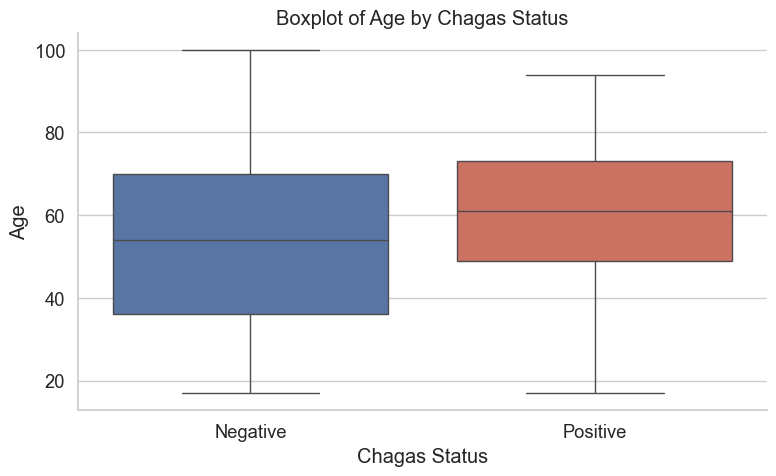

In [8]:
code_df["Chagas"] = code_df["chagas"].map({0: "Negative", 1: "Positive"})

sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=code_df,
    x="Chagas",
    y="age",
    palette=["#4C72B0", "#DD6552"]
)

plt.title("Boxplot of Age by Chagas Status")
plt.xlabel("Chagas Status")
plt.ylabel("Age")

sns.despine()
plt.tight_layout()

plt.show()

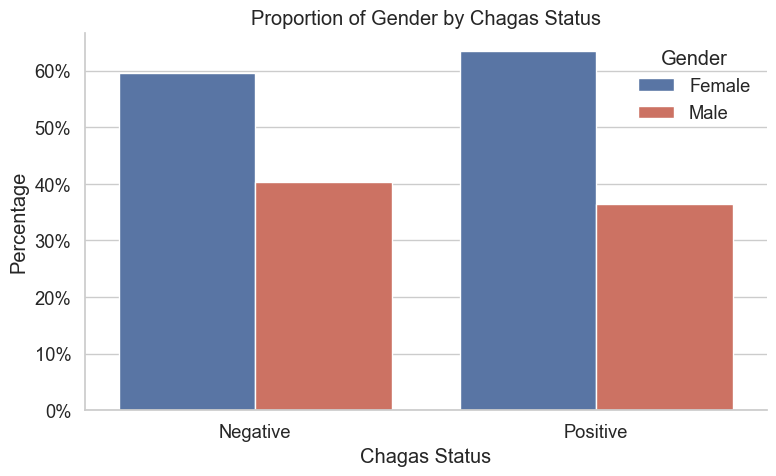

In [9]:
gender_chagas = (
    code_df.groupby("chagas")["is_male"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

gender_chagas["Gender"] = gender_chagas["is_male"].map({False: "Female", True: "Male"})
gender_chagas["Chagas"] = gender_chagas["chagas"].map({0: "Negative", 1: "Positive"})

sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_chagas,
    x="Chagas",
    y="proportion",
    hue="Gender",
    palette=["#4C72B0", "#DD6552"]
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("Proportion of Gender by Chagas Status")
plt.ylabel("Percentage")
plt.xlabel("Chagas Status")

plt.legend(title="Gender", frameon=False)
sns.despine()

plt.tight_layout()
plt.show()

EDA for ECG's

In [ ]:

exam_id_0 = code_df.loc[code_df["chagas"] == 0, "exam_id"].sample(1, random_state=1).iloc[0]
exam_id_1 = code_df.loc[code_df["chagas"] == 1, "exam_id"].sample(1, random_state=1).iloc[0]


print("Random chagas 0 exam_id:", exam_id_0)
print("Random chagas 1 exam_id:", exam_id_1)

ecg_0, row_0 = get_code_ecg(code_df, exam_id_0)
print("ECG shape for chagas 0:", ecg_0.shape)

ecg_1, row_1 = get_code_ecg(code_df, exam_id_1)
print("ECG shape for chagas 1:", ecg_1.shape)


Random chagas 0 exam_id: 3004756
Random chagas 1 exam_id: 2680498
ECG shape for chagas 0: (4096, 12)
ECG shape for chagas 1: (4096, 12)


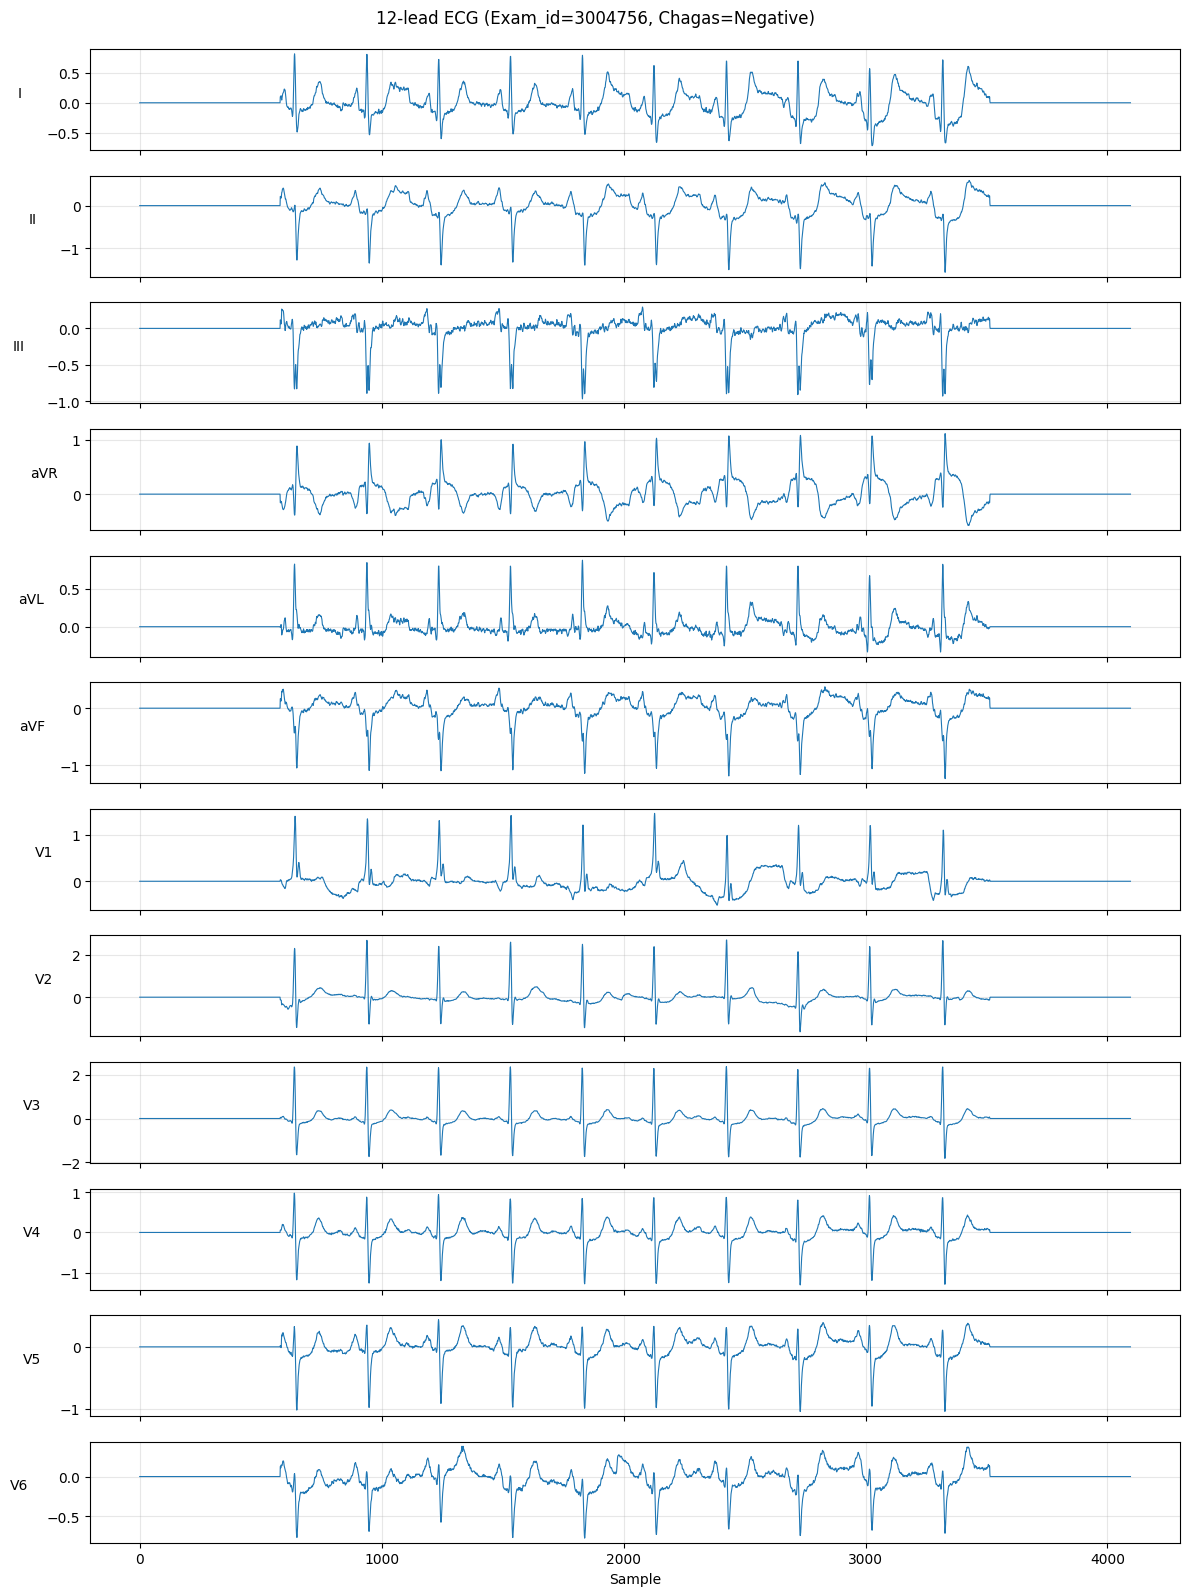

In [6]:
lead_names = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

fig, axes = plt.subplots(12, 1, figsize=(12, 16), sharex=True)

for i in range(12):
    axes[i].plot(ecg_0[:, i], linewidth=0.8)
    axes[i].set_ylabel(lead_names[i], rotation=0, labelpad=20)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f"12-lead ECG (Exam_id={row_0['exam_id']}, Chagas=Negative)", y=0.995)
axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

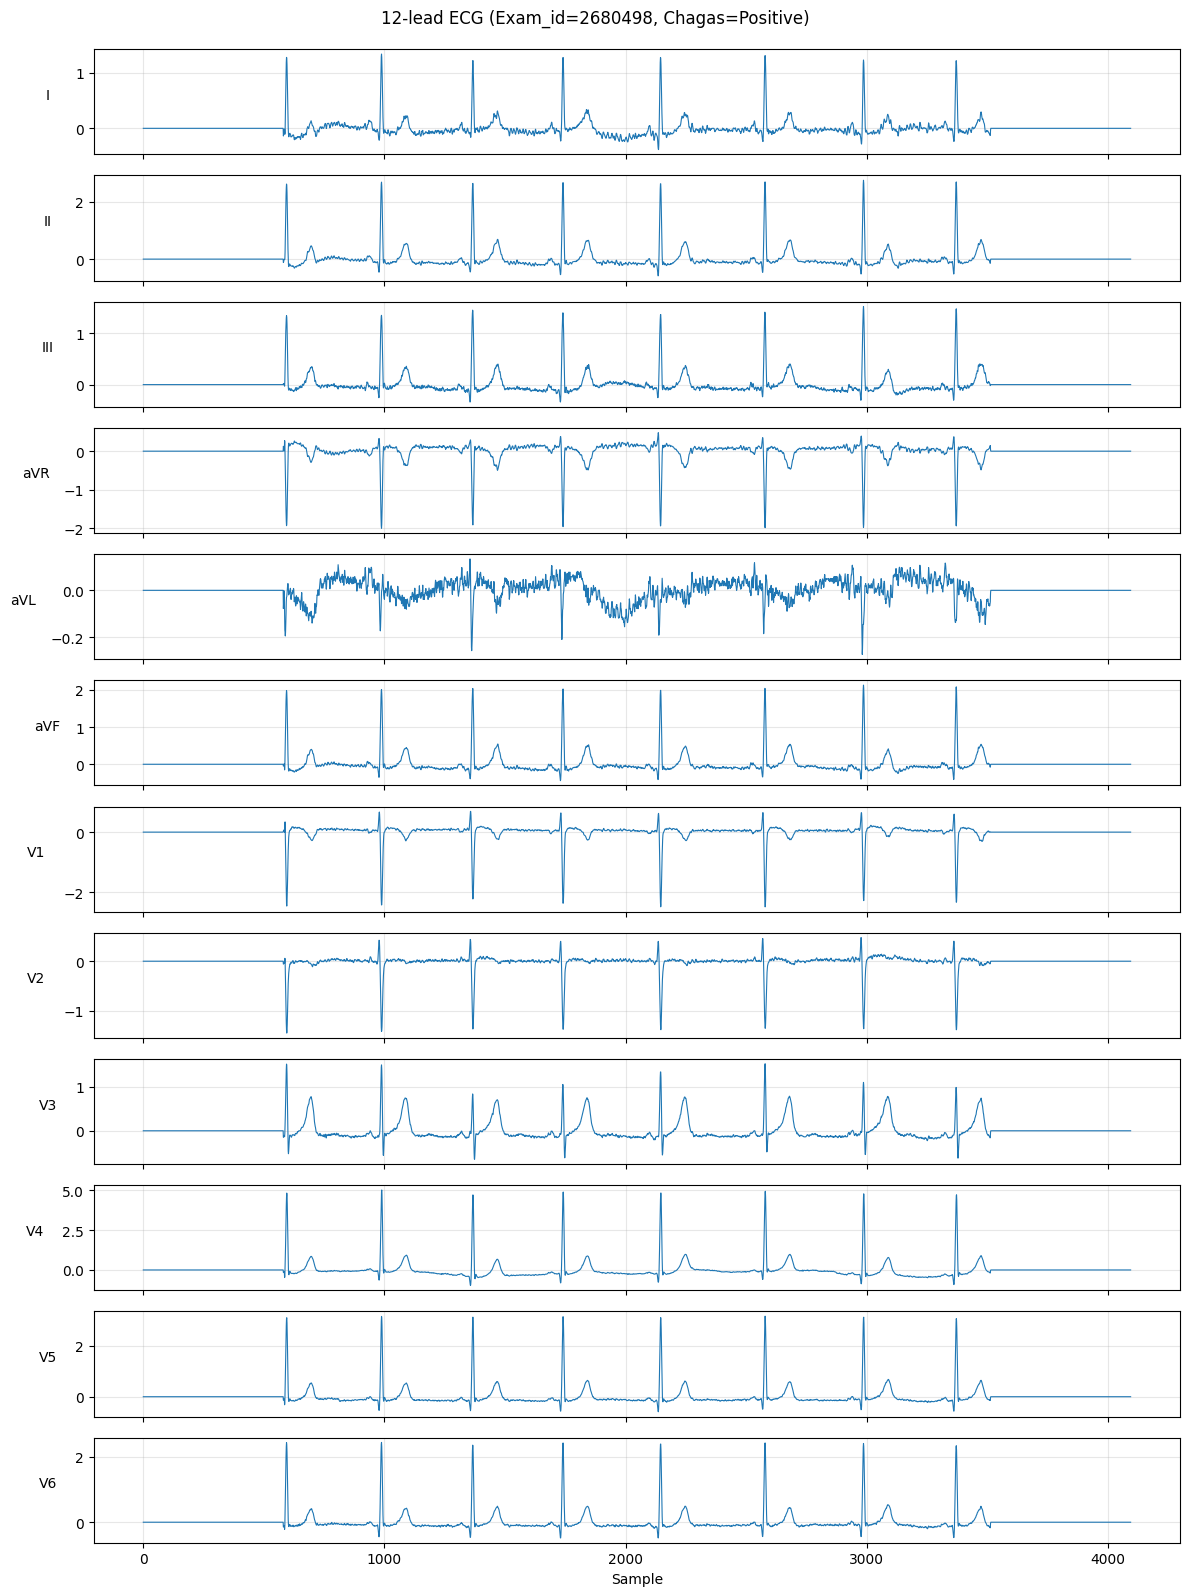

In [ ]:
fig, axes = plt.subplots(12, 1, figsize=(12, 16), sharex=True)

for i in range(12):
    axes[i].plot(ecg_1[:, i], linewidth=0.8)
    axes[i].set_ylabel(lead_names[i], rotation=0, labelpad=20)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f"12-lead ECG (Exam_id={row_1['exam_id']}, Chagas=Positive)", y=0.995)
axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()


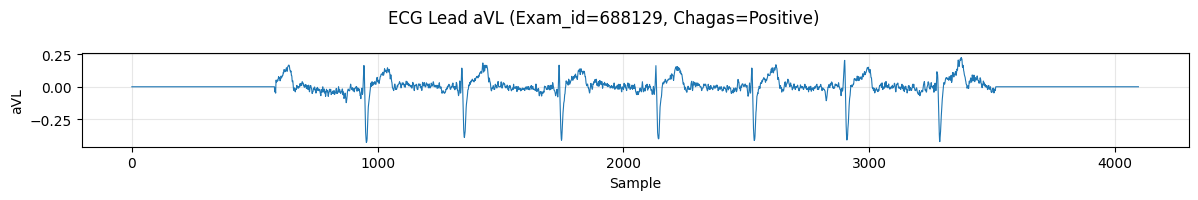

In [33]:
exam_id_2 = code_df.loc[code_df["chagas"] == 1, "exam_id"].sample(1, random_state=2).iloc[0]
ecg_2, row_2 = get_code_ecg(code_df, exam_id_2)
lead_names = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

lead_idx = 4  # for example: lead 4 if zero-based indexing
fig, ax = plt.subplots(figsize=(12, 2))

ax.plot(ecg_2[:, lead_idx], linewidth=0.8)
ax.set_ylabel(lead_names[lead_idx])
ax.set_xlabel("Sample")
ax.grid(True, alpha=0.3)

fig.suptitle(f"ECG Lead {lead_names[lead_idx]} (Exam_id={row_2['exam_id']}, Chagas=Positive)")
plt.tight_layout()
plt.show()

In [14]:
rows = []

sample_df = code_df.sample(10000, random_state=42)

for exam_id in sample_df["exam_id"]:
    ecg, _ = get_code_ecg(code_df, exam_id)
    rows.append({
        "exam_id": exam_id,
        "min": ecg.min(),
        "max": ecg.max(),
        "mean": ecg.mean(),
        "std": ecg.std()
    })

stats_df = pd.DataFrame(rows)
print(stats_df.describe())

            exam_id           min           max          mean           std
count  1.000000e+04  10000.000000  10000.000000  10000.000000  10000.000000
mean   1.518285e+06     -4.703711      4.998383     -0.073944      0.911823
std    1.112453e+06      4.819002      5.228157      0.430176      1.004034
min    2.120000e+02   -243.905167      0.000000     -3.902220      0.000000
25%    6.494640e+05     -5.138913      2.659861     -0.098769      0.272723
50%    1.274316e+06     -3.361513      3.592395      0.000148      0.441707
75%    2.027230e+06     -2.384329      5.254714      0.002563      1.198944
max    4.416427e+06      0.000000    219.650055      3.864378     10.468212


In [15]:
q1 = stats_df["max"].quantile(0.25)
q3 = stats_df["max"].quantile(0.75)
iqr = q3 - q1

threshold_high = q3 + 1.5 * iqr
threshold_low = q1 - 1.5 * iqr
print(f"Max value outlier thresholds: {threshold_low:.2f} to {threshold_high:.2f}")

Max value outlier thresholds: -1.23 to 9.15


In [ ]:
def is_flat_ecg(ecg, std_threshold=0.01):
    return ecg.std() < std_threshold
flat_ids = []
flat_exam_id = None

for exam_id in code_df["exam_id"]:
    ecg, _ = get_code_ecg(code_df, exam_id)
    
    if is_flat_ecg(ecg):
        flat_exam_id = exam_id
        break

print("Flat ECG exam_id:", flat_exam_id)

Flat ECG exam_id: 1460876


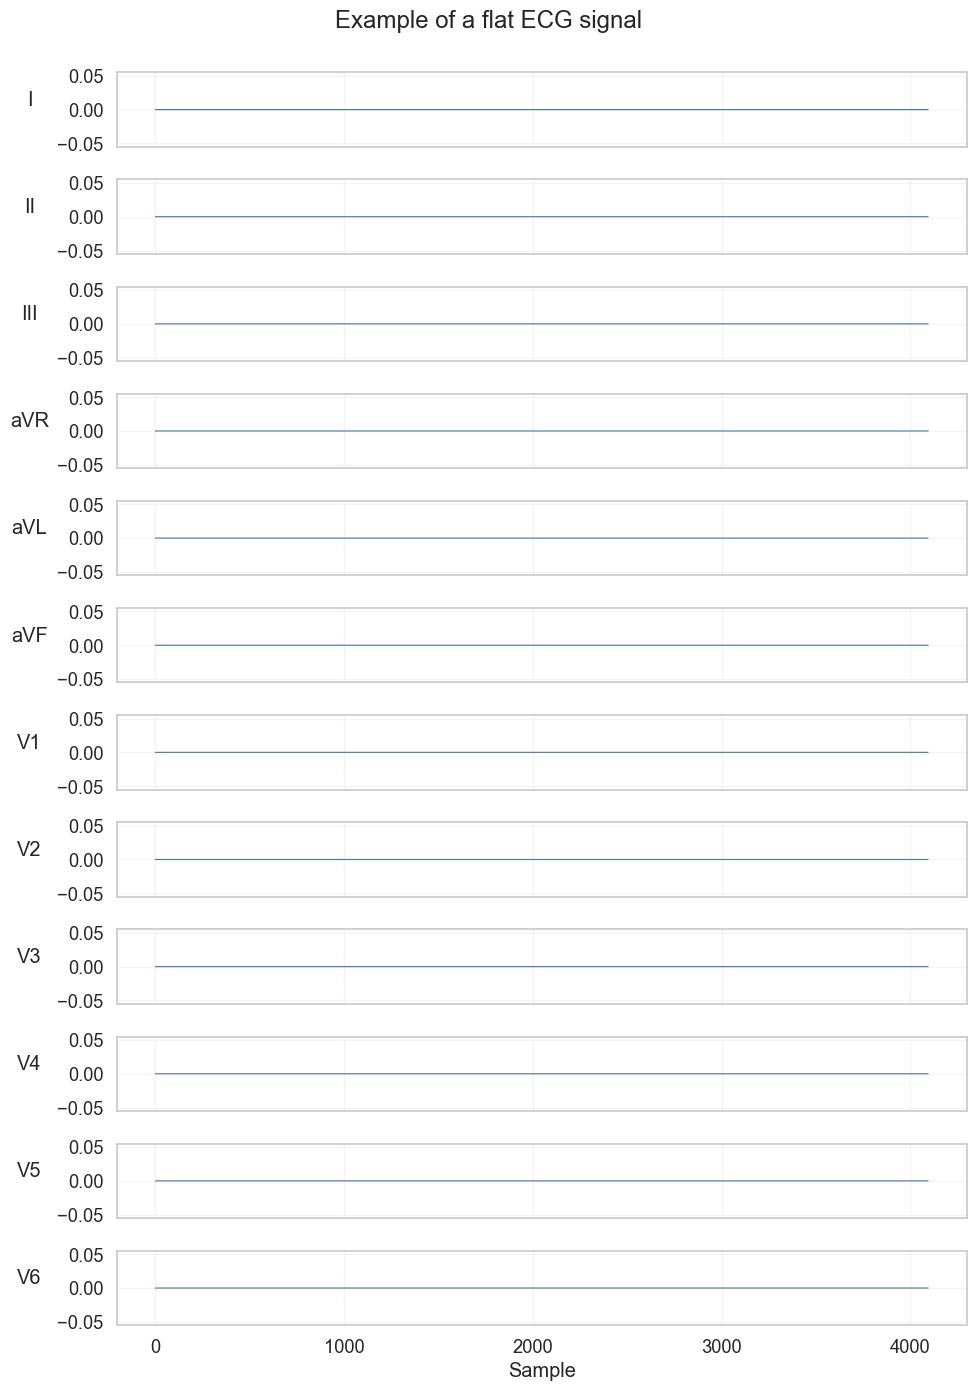

In [76]:
import matplotlib.pyplot as plt

ecg_flat, row = get_code_ecg(code_df, flat_exam_id)

lead_names = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

fig, axes = plt.subplots(12, 1, figsize=(10, 14), sharex=True)

for i in range(12):
    axes[i].plot(ecg_flat[:, i], linewidth=0.8)
    axes[i].set_ylabel(lead_names[i], rotation=0, labelpad=20)
    axes[i].grid(True, alpha=0.2)

axes[-1].set_xlabel("Sample")
plt.suptitle("Example of a flat ECG signal", y=0.995)

plt.tight_layout()
plt.show()

In [78]:
#show 'chagas' label where exam_id == 1460876 in code_df
chagas_label = code_df.loc[code_df["exam_id"] == 1460876, "chagas"].values[0]
print(f"Exam_id 1460876 has chagas label: {chagas_label}")


Exam_id 1460876 has chagas label: 0


In [16]:
import h5py
import numpy as np
from pathlib import Path

base = Path("../data/CODE-15%")
files = sorted(base.glob("exams_part*.hdf5"))

valid_ids = code_df["exam_id"].to_numpy()

total = 0
flat = 0

for fp in files:
    with h5py.File(fp, "r") as f:
        exam_ids = f["exam_id"][:]
        X = f["tracings"][:]

        mask = np.isin(exam_ids, valid_ids)

        X = X[mask]

        stds = X.reshape(X.shape[0], -1).std(axis=1)
        zfrac = (np.abs(X) < 1e-6).reshape(X.shape[0], -1).mean(axis=1)

        is_flat = (stds < 0.01) | (zfrac > 0.95)

        flat += is_flat.sum()
        total += X.shape[0]

print(f"Flat ECGs in labeled subset: {flat}/{total} = {flat/total:.4%}")

Flat ECGs in labeled subset: 711/343424 = 0.2070%


In [ ]:
def is_extreme_ecg(ecg, lower=-1, upper=9):
    return (ecg.max() > upper) or (ecg.min() < lower)

extreme_count = 0

for exam_id in sample_df["exam_id"]:
    ecg, _ = get_code_ecg(code_df, exam_id)
    
    if is_extreme_ecg(ecg):
        extreme_count += 1

print(extreme_count)

NameError: name 'sample_df' is not defined

In [18]:
import h5py
import numpy as np
from pathlib import Path

base = Path("../data/CODE-15%")
files = sorted(base.glob("exams_part*.hdf5"))

# only Chagas-positive ECGs
valid_ids = code_df[code_df["chagas"] == 1]["exam_id"].to_numpy()

total = 0
flat = 0

for fp in files:
    with h5py.File(fp, "r") as f:
        exam_ids = f["exam_id"][:]
        X = f["tracings"][:]

        mask = np.isin(exam_ids, valid_ids)
        X = X[mask]

        stds = X.reshape(X.shape[0], -1).std(axis=1)
        zfrac = (np.abs(X) < 1e-6).reshape(X.shape[0], -1).mean(axis=1)

        is_flat = (stds < 0.01) | (zfrac > 0.95)

        flat += is_flat.sum()
        total += X.shape[0]

print(f"Flat ECGs (Chagas=1): {flat}/{total} = {flat/total:.4%}")

Flat ECGs (Chagas=1): 2/6561 = 0.0305%


ECG shape for chagas 0: (4096, 12)


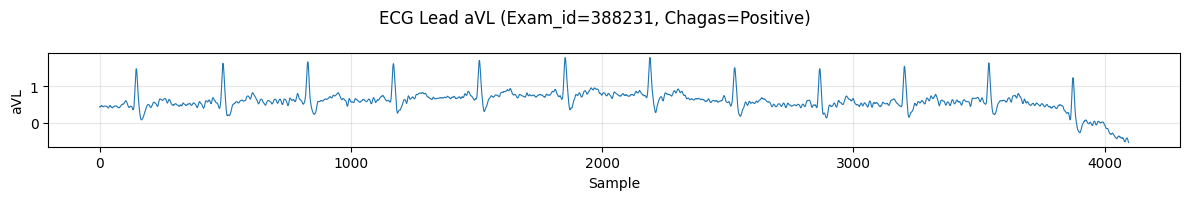

In [ ]:
ecg, row = get_code_ecg(code_df, "exam_id")
print("ECG shape for chagas 0:", ecg.shape)


lead_idx = 4
fig, ax = plt.subplots(figsize=(12, 2))

ax.plot(ecg[:, lead_idx], linewidth=0.8)
ax.set_ylabel(lead_names[lead_idx])
ax.set_xlabel("Sample")
ax.grid(True, alpha=0.3)

fig.suptitle(f"ECG Lead {lead_names[lead_idx]} (Exam_id={row['exam_id']}, Chagas=Positive)")
plt.tight_layout()
plt.show()


ECG shape for chagas 0: (4096, 12)


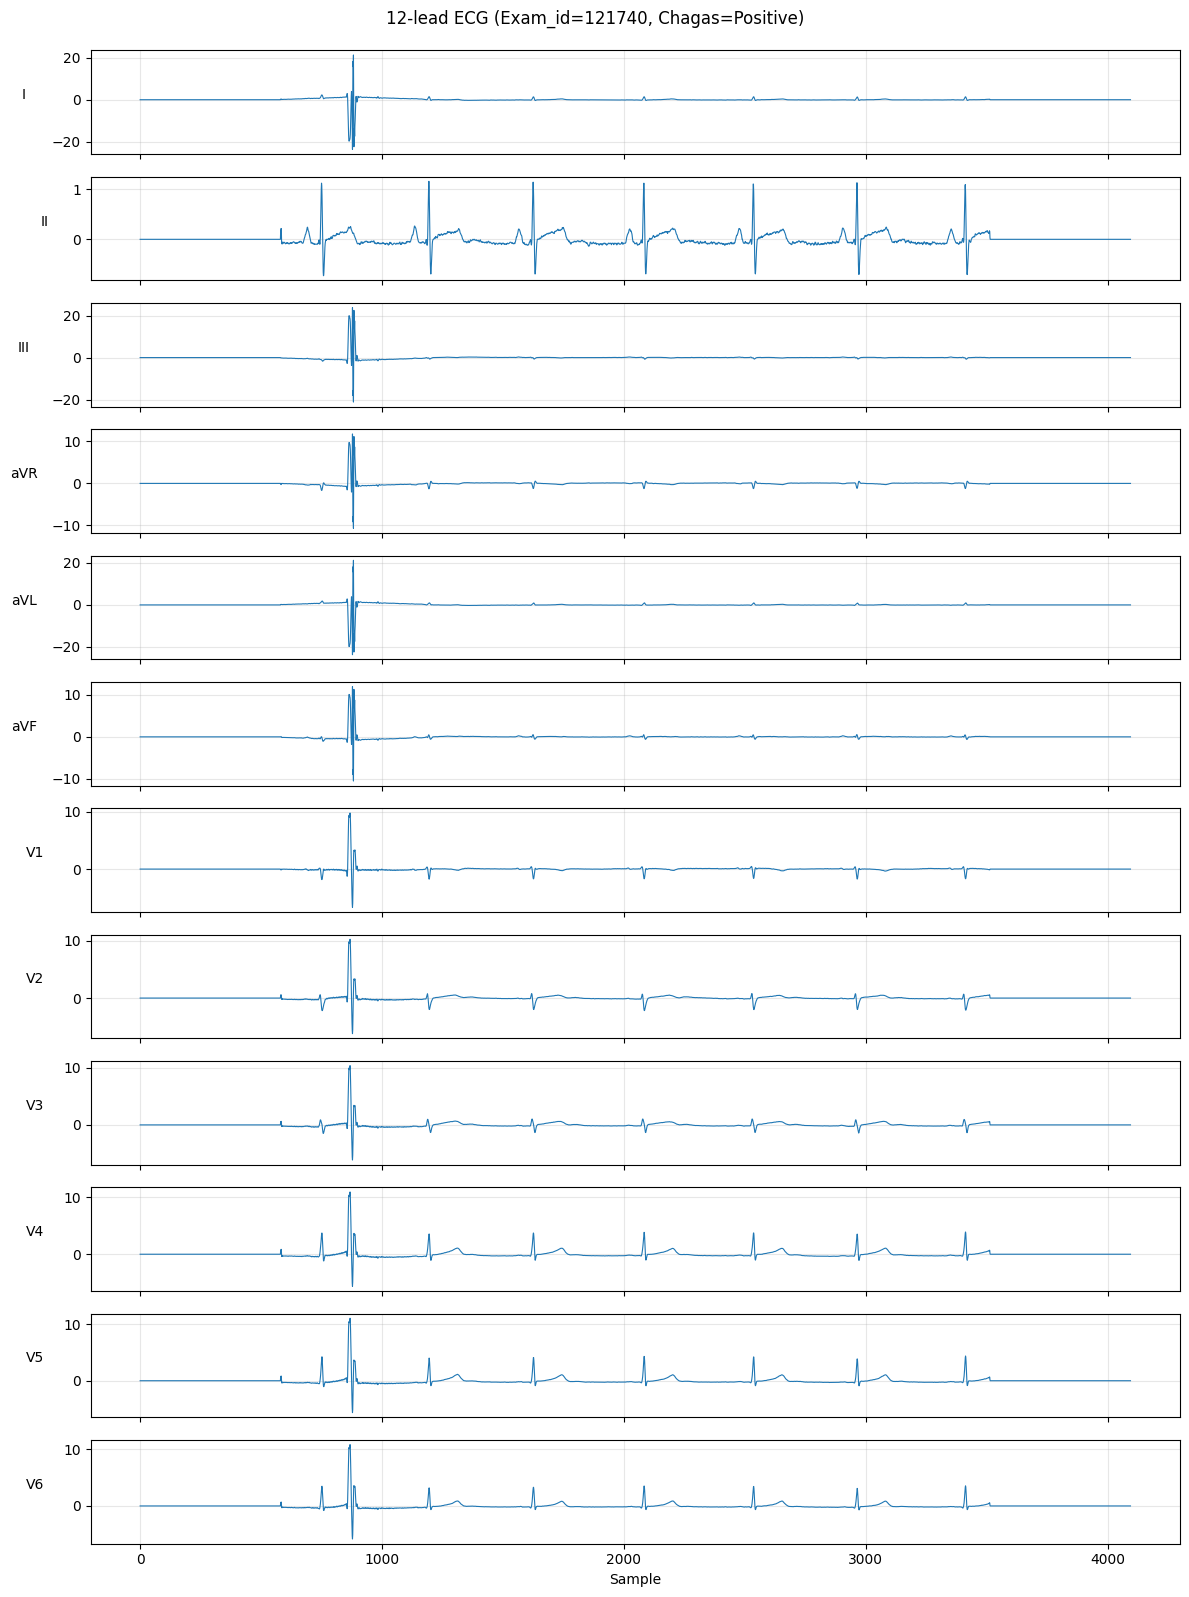

In [ ]:
exam_id = code_df["exam_id"].sample(1).iloc[0]
ecg, row = get_code_ecg(code_df, exam_id)
print("ECG shape for chagas 0:", ecg.shape)

fig, axes = plt.subplots(12, 1, figsize=(12, 16), sharex=True)

for i in range(12):
    axes[i].plot(ecg[:, i], linewidth=0.8)
    axes[i].set_ylabel(lead_names[i], rotation=0, labelpad=20)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f"12-lead ECG (Exam_id={row['exam_id']}, Chagas=Positive)", y=0.995)
axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()
# Check exam_id = 121740